# Sprint 6 - Proyecto del Módulo I (Sesiones)

¡Felicidades! Has concluido con la primera etapa de tu camino para convertirte en un analista o científico de datos. Hagamos un resumen de lo aprendido hasta ahora:

* Conoces los fundamentos del programación con Python. Siempre ten en cuenta que la programación no es el fin del análisis o ciencia de datos, sino una de las muchas herramientas a tu disposición.
* Tienes claro que analizar datos involucra siempre entender el contexto de cada caso y diagnosticar los datos disponibles. Los procedimientos que apliques podrían ser automatizables, pero tu criterio y comprensión de los problemas reales no lo son. 
* Sabes manipular datos en presentaciones tabulares. Una gran parte de la información viene estructurada de esta forma, y si en algún momento te enuentras con datos en otra presentación, ten claro que existen mecanismos para llevarlos hacia tablas.
* Ya eres capaz de llevar a cabo el análisis de datos más usual aplicando tus conocimientos en estadística y visualización. Recuerda que explorar la información implica tener claro indicadores de interés para el contexto y estudiar su comportamiento a fin de brindar conclusiones de valor.

Vamos a repasar estos puntos con un nuevo caso de estudio. 

**ADVERTENCIA:** Los códigos implementados en este documento no pretenden ser la solución explícita del proyecto a entregar en la plataforma, sino una ampliación de lo que allí te solicitan.

## Entendimiento del contexto

La industria de los videojuegos se ha consolidado como uno de los sectores de entretenimiento más grandes y dinámicos del mundo, superando en ingresos a industrias tradicionales como el cine y la música. Su crecimiento se debe a la combinación de avances tecnológicos —realidad virtual, inteligencia artificial, gráficos de alta fidelidad— y la diversificación de plataformas, desde consolas y PC hasta dispositivos móviles y servicios de cloud gaming. Este ecosistema no solo atrae a jugadores de todas las edades y regiones, sino también a empresas que encuentran en los videojuegos una oportunidad para innovar en experiencias interactivas y modelos de negocio.

La dinámica del sector está altamente influenciada por los *scores* de la crítica especializada y de los usuarios, ya que las reseñas y valoraciones pueden impactar directamente en las ventas y en la percepción de marca de los desarrolladores y distribuidores. A su vez, los ratings por edad y contenido (como los de la ESRB o PEGI) también juegan un rol importante en la segmentación de jugadores y en la aceptación de los títulos en diferentes regiones. Así, los videojuegos no solo representan un producto cultural y de entretenimiento, sino un campo fertil para el desarrollo de empresas de capitales millonarios.

Has sido contratado por un distribuidor minorista de videojuegos a nivel mundial, y tu primer trabajo consiste en generar un estudio para identificar los patrones asociados al éxito de un videojuego. Este informe será un insumo fundamental para que la empresa detecte proyectos prometedores, y planifique campañas publicitarias enfocadas en personalizar experiencias de jugadores y maximizar ingresos.

## Entendimiento de los datos

La empresa ha compartido contigo la tabla **games** que deberás cargar a continuación.

In [1]:
# Cargar librerias
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

In [ ]:
# Cargar datos
df_games = pd.read_csv("games.csv")

Este dataset presenta infromación sobre ventas, scores y rating de videojuegos que ha comercializado la empresa desde 1980 hasta 2016. Cuenta con poco menos de 17 mil registros y 11 columnas descritas a continuación:

* Name: Nombre oficial del videojuego vendido. 
* Platform: Consola en la que salió el videojuego.
* Year_of_Release: Año de lanzamiento del videojuego al mercado.
* Genre: Género del videojuego.
* NA_sales: Ventas en USD(x100) en Norteamérica.
* EU_sales: Ventas en USD(x100) en Europa.
* JP_sales: Ventas en USD(x100) en Japón.
* Other_sales: Ventas en USD(x100) en el resto del mundo.
* Critic_Score: Calificación promedio entre 0 y 100 dada por la crítica especializada. 
* User_Score: Calificación promedio entre 0 y 10 dada por los jugadodores.
* Rating: Clasificación de contenido recomendado por la ESRB.

Visto esto, realiza un diagnóstico de los datos y genera un plan de acción para su preparación. Conviene que mires si existen duplicados igualmente en esta etapa.

In [3]:
# Mirar la estructura del dataset
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Mirar una muestra de los datos
df_games.sample(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
2717,Nintendo Presents: New Style Boutique 2 - Fash...,3DS,2015.0,Misc,0.03,0.66,0.02,0.04,NaN,NaN,NaN
64,Halo: Reach,X360,2010.0,Shooter,7.04,1.95,0.08,0.79,91.0,7.9,M
6540,We Cheer 2,Wii,2009.0,Simulation,0.24,0.00,0.00,0.02,64.0,tbd,E10+
11935,Cho~ricchi! Tamagotchi no Puchi Puchi Omisecchi,3DS,2012.0,Action,0.00,0.00,0.07,0.00,NaN,NaN,NaN
11694,"Ni Hao, Kai-lan: Super Game Day",PS2,2009.0,Misc,0.04,0.03,0.00,0.01,NaN,tbd,E
5632,No.1 Muscle Ranking - Kinniku Banzuke Vol. 1: ...,PS,1999.0,Sports,0.00,0.00,0.30,0.02,NaN,NaN,NaN
14855,Max Payne 2: The Fall of Max Payne,PC,2003.0,Shooter,0.00,0.02,0.00,0.00,86.0,9,M
5309,Destiny: The Taken King,X360,2015.0,Shooter,0.24,0.08,0.00,0.03,NaN,4.4,T
1351,SimCity (2013),PC,2013.0,Simulation,0.48,0.77,0.00,0.17,64.0,2.2,E10+
849,Need for Speed: The Run,PS3,2011.0,Action,0.58,1.04,0.03,0.36,64.0,6.4,T


In [5]:
# Mirar plataformas existentes
df_games['Platform'].value_counts().sort_index()

Platform
2600     133
3DO        3
3DS      520
DC        52
DS      2151
GB        98
GBA      822
GC       556
GEN       29
GG         1
N64      319
NES       98
NG        12
PC       974
PCFX       1
PS      1197
PS2     2161
PS3     1331
PS4      392
PSP     1209
PSV      430
SAT      173
SCD        6
SNES     239
TG16       2
WS         6
Wii     1320
WiiU     147
X360    1262
XB       824
XOne     247
Name: count, dtype: int64

In [6]:
# Mirar los generos existentes
df_games['Genre'].value_counts().sort_index()

Genre
Action          3369
Adventure       1303
Fighting         849
Misc            1750
Platform         888
Puzzle           580
Racing          1249
Role-Playing    1498
Shooter         1323
Simulation       873
Sports          2348
Strategy         683
Name: count, dtype: int64

In [7]:
# Generar un resumen estadistico de las ventas
df_games[["NA_sales","EU_sales","JP_sales","Other_sales"]].describe().round(1)

,NA_sales,EU_sales,JP_sales,Other_sales
count,16715.0,16715.0,16715.0,16715.0
mean,0.3,0.1,0.1,0.0
std,0.8,0.5,0.3,0.2
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0
50%,0.1,0.0,0.0,0.0
75%,0.2,0.1,0.0,0.0
max,41.4,29.0,10.2,10.6


In [8]:
# Generar un resumen estadístico del score de criticos
df_games['Critic_Score'].describe().round(1)

count    8137.0
mean       69.0
std        13.9
min        13.0
25%        60.0
50%        71.0
75%        79.0
max        98.0
Name: Critic_Score, dtype: float64

In [9]:
# Mirar los scores de usuarios posibles
df_games['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [10]:
# Mirar los ratings existentes
df_games['Rating'].value_counts().sort_index()

Rating
AO         1
E       3990
E10+    1420
EC         8
K-A        3
M       1563
RP         3
T       2961
Name: count, dtype: int64

In [11]:
# Verificar duplicados existentes
df_games.duplicated().sum()

0

In [12]:
# Verificar duplicados existentes en columnas concretas (entidades)
df_games[["Name","Platform","Year_of_Release","Genre"]].duplicated().sum()

2

In [13]:
# Mirar duplicados de columnas concretas (entidades)
df_games[df_games[["Name","Platform","Year_of_Release","Genre"]].duplicated()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
14244,NaN,GEN,1993.0,NaN,0.0,0.00,0.03,0.0,NaN,NaN,NaN
16230,Madden NFL 13,PS3,2012.0,Sports,0.0,0.01,0.00,0.0,83.0,5.5,E


**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

* Cambiar los nombres de las columnas a formato *snake_case*.
* Eliminar los valores perdidos de las columnas Name y Genre visto que son solamente 2 filas. La misma acción para Year_of_Release que tiene cerca de 250 valores perdidos (aprox. 1.5% del total de filas)
* Agrupar las opciones existentes de la columna Platform en tipologías de forma que se cree la columna platform_group (i.e Nintendo, Playstation, etc.). Esto, ya que existen muchas opciones posibles y desbalanceadas lo cual puede dificultar la interpretacion de resultados posteriores.  
* Sustituir el valor "tbd" de la columna User_Score por un valor perdido numérico. De esta manera posteriormente la columna se puede transformar a flotante.
* Una vez transformada la columna User_Score, multiplicar por 10 sus valores de forma que se estandaricen las magnitudes con Critic_Score y facilitar así su comparación.
* Si bien ambas columnas de *score* cuentan con valores ausentes no hay que darles ningún tratamiento en particular. Por un lado son una proporcion importante del dataset; y por otro, un valor perdido aquí reflejaría una realidad propia del contexto, y es que hay videojuegos que simplemente no han sido calificados. 
* En la columna Rating cambiar las opciones existentes por otros valores que den una interpretación más semántica de los datos y faciliten así su interpretación durante el análisis.
* En esta columna también se pueden asignar los valores perdidos como pendientes de calificación pues esta tipología existe en ESRB y resulta coherente con el contexto.
* Generar una nueva columna total_sales que agregue las ventas a nivel mundial. Esto ya que al ser este indicador uno de los que se analizarán, conviene tener un valor agregado que evite códigos redundantes posteriormente.
* Eliminar duplicados detectados en el dataset pues corresponden seguramente a errores de registro. 

## Preparación de datos

Implementa el plan de acción de forma organizada.

In [14]:
# Cambiar nombres de columnas a fomrato snake_case
df_games.columns = [nombre.lower().replace(" ","_") for nombre in df_games.columns]
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [15]:
# Eliminar valores perdidos en columna name, genre y year_of_release
df_games = df_games.dropna(subset = ["name", "genre", "year_of_release"])
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


In [16]:
# Crear columna con grupos de plataformas
def fun_plataforma (x):
    if x in ["3DS","DS","GB","GBA","GC","N64","NES","SNES","Wii","WiiU"]:
        return "Nintendo"
    elif x in ["PC","PCFX"]:
        return "PC"
    elif x in ["PS","PS2","PS3","PS4","PSP","PSV"]:
        return "PlayStation"
    elif x in ["X360","XB","XOne"]:
        return "XBox"
    else:
        return "Other"

df_games["platform_group"] = df_games["platform"].apply(fun_plataforma)
df_games["platform_group"].value_counts(normalize = True) * 100

platform_group
PlayStation    40.361226
Nintendo       37.515203
XBox           13.877402
PC              5.825833
Other           2.420336
Name: proportion, dtype: float64

In [17]:
# Sustituir "tbd" por valor perdido numérico en user_score
df_games["user_score"] = df_games["user_score"].replace("tbd",np.nan)
df_games["user_score"].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', '8.8', '6.9', '9.4', '6.8', '6.1',
       '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6', '3.7',
       '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9', '3.1',
       '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3', '2.7',
       '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0', '1.6',
       '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2', '2.3',
       '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'], dtype=object)

In [18]:
# Transformar user_Score a flotate
df_games["user_score"] = df_games["user_score"].astype(float)
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
 11  platform_group   16444 non-null  object 
dtypes: float64(7), object(5)
memory usage: 1.6+ MB


In [19]:
# Multiplicar por 10 valor de user_score
df_games["user_score"] = df_games["user_score"] * 10
df_games[["critic_score","user_score"]].describe().round(1)

,critic_score,user_score
count,7983.0,7463.0
mean,69.0,71.3
std,13.9,15.0
min,13.0,0.0
25%,60.0,64.0
50%,71.0,75.0
75%,79.0,82.0
max,98.0,97.0


In [20]:
# Cambiar rating por valores más semánticos
def fun_rating (x):
    if x == "E" or x == "K-A":
        return "Everyone"
    elif x == "T":
        return "Teens"
    elif x == "M":
        return "Mature"
    elif x == "E10+":
        return "Everyone 10y+"
    elif x == "EC":
        return "Early Childhood"
    elif x == "RP":
        return "Pending"
    elif x == "AO":
        return "Adults Only"
    else:
        return "Pending"

df_games["rating"] = df_games["rating"].apply(fun_rating)
df_games["rating"].value_counts()

rating
Pending            6677
Everyone           3924
Teens              2905
Mature             1536
Everyone 10y+      1393
Early Childhood       8
Adults Only           1
Name: count, dtype: int64

In [21]:
# Generar columna total_sales
df_games["total_sales"] = df_games[["na_sales","eu_sales","jp_sales","other_sales"]].sum(axis=1)
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
 11  platform_group   16444 non-null  object 
 12  total_sales      16444 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.8+ MB


In [22]:
# Eliminar duplicados detectados
df_games = df_games.drop_duplicates(subset = ["name","platform","year_of_release","genre"])
df_games.duplicated(subset = ["name","platform","year_of_release","genre"]).sum()

0

In [23]:
# Visualizar dataframe limpio
df_games.sample(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,platform_group,total_sales
16099,Sengoku Hime: Senran ni Mau Otometachi,PSP,2009.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,Pending,PlayStation,0.01
1085,Madden NFL 2001,PS,2000.0,Sports,1.58,0.05,0.00,0.04,90.0,68.0,Everyone,PlayStation,1.67
15924,Pirates PlundArrr,Wii,2010.0,Action,0.02,0.00,0.00,0.00,60.0,NaN,Everyone 10y+,Nintendo,0.02
10738,EyeToy: Operation Spy,PS2,2005.0,Action,0.05,0.04,0.00,0.01,53.0,NaN,Everyone,PlayStation,0.10
2212,Bentley's Hackpack,GBA,2005.0,Misc,0.67,0.25,0.00,0.02,NaN,NaN,Pending,Nintendo,0.94
5158,GoldenEye: Rogue Agent,GC,2004.0,Shooter,0.28,0.07,0.00,0.01,60.0,67.0,Teens,Nintendo,0.36
15330,Dragon's Lair,DS,2010.0,Platform,0.02,0.00,0.00,0.00,63.0,NaN,Everyone 10y+,Nintendo,0.02
4114,NFL Xtreme 2,PS,1999.0,Sports,0.27,0.18,0.00,0.03,NaN,NaN,Pending,PlayStation,0.48
15484,Oil Rush,PC,2012.0,Strategy,0.00,0.02,0.00,0.00,67.0,65.0,Pending,PC,0.02
3169,Lemony Snicket's A Series of Unfortunate Events,PS2,2004.0,Platform,0.31,0.24,0.00,0.08,63.0,57.0,Everyone,PlayStation,0.63


## Analisis exploratorio de datos

Responde las siguientes preguntas que te permitan identificar patrones asociados a estos datos.

### ¿Cómo se han comportado las ventas y la cantidad de juegos a través de los años?

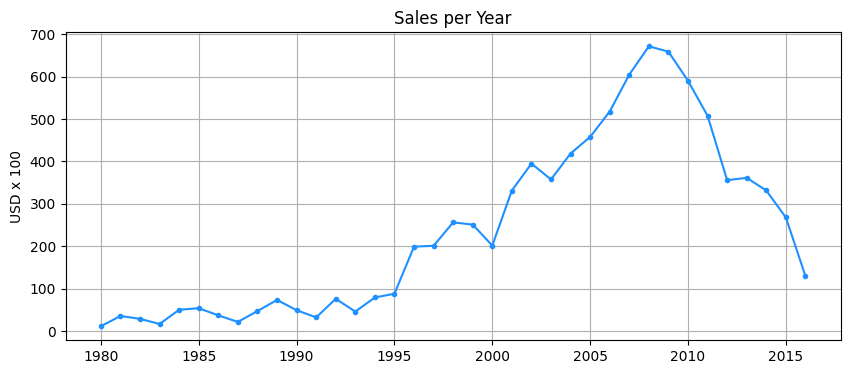

In [24]:
# Visualizar evolución de ventas
sales_per_year = df_games.groupby('year_of_release')['total_sales'].sum()

sales_per_year.plot(
    xlabel = "",
    ylabel="USD x 100",
    title="Sales per Year",
    figsize = [10,4],
    grid = True,
    marker = ".",
    color = "dodgerblue"
)

plt.show()

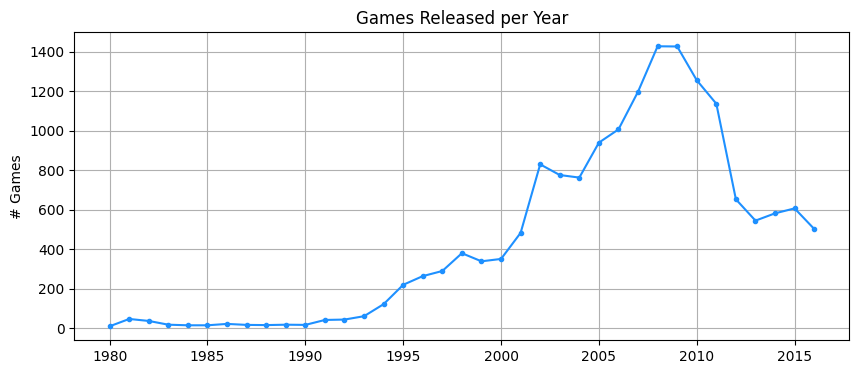

In [25]:
# Visualizar evolución de cantidad de juegos
games_per_year = df_games.groupby('year_of_release')['name'].count()

games_per_year.plot(
    xlabel = "",
    ylabel="# Games",
    title="Games Released per Year",
    figsize = [10,4],
    grid = True,
    marker = ".",
    color = "dodgerblue"
)

plt.show()

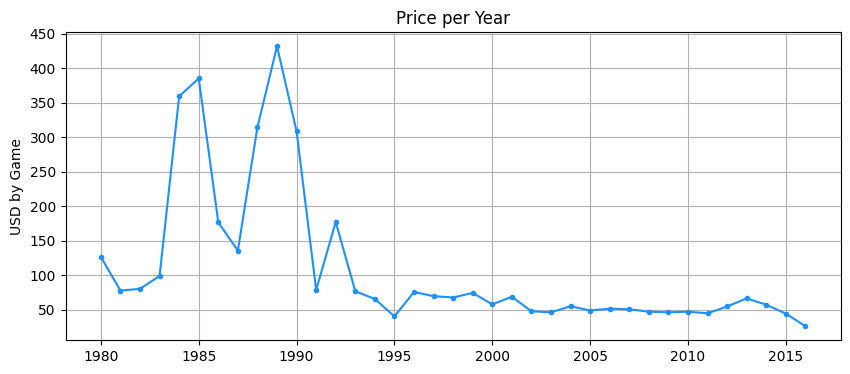

In [26]:
# Visualizar precio promedio por videojuego
(100 * sales_per_year / games_per_year).plot(
    xlabel = "",
    ylabel="USD by Game",
    title="Price per Year",
    figsize = [10,4],
    grid = True,
    marker = ".",
    color = "dodgerblue"
)

plt.show()

**CONCLUSIONES**

* La oferta de videojuegos tiene su "boom" a partir de 1995, cuando empieza a diversificarse la oferta de consolas en los hogares y los precios de videojuegos muestran una reducción significativa. Por tanto los patrones a buscar deberían considerar información a partir de este año en cuanto el mercado habría tenido cambios significativos por lo expuesto.
* Igualmente se evidencia un cambio de comportamiento a partir del año 2009, producto de la crisis económica mundial que acarreó probablemente nuevas dinámicas en el mercado de los videojuegos. Sin embargo, al ser información más reciente conviene mantenerla en el dataset pues contendría los patrones que se busca evidenciar.

In [27]:
# Eliminar información previa a 1995
df_games = df_games.query("year_of_release >= 1995")

### ¿Cómo se han comportado los indicadores en los distintos grupos de plataformas?

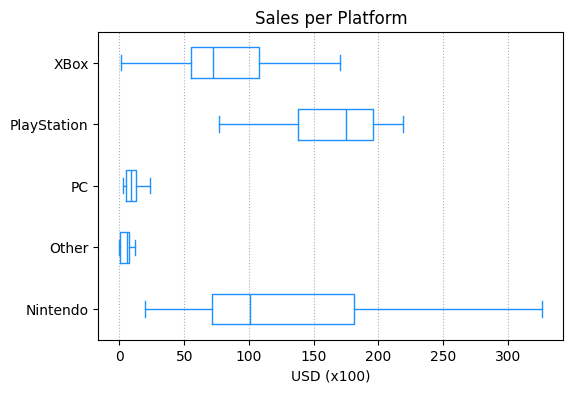

In [28]:
# Visualizar comportamiento de ventas
sales_per_platform = df_games.pivot_table(
    index = "year_of_release",
    columns = "platform_group",
    values = "total_sales",
    aggfunc = "sum"
)

sales_per_platform.plot(
    kind="box",
    xlabel="USD (x100)",
    ylabel="",
    title="Sales per Platform",
    vert = False,
    figsize = [6,4],
    showfliers = False,
    color = "dodgerblue"
)

plt.grid(axis = "x", linestyle = ":")
plt.show()

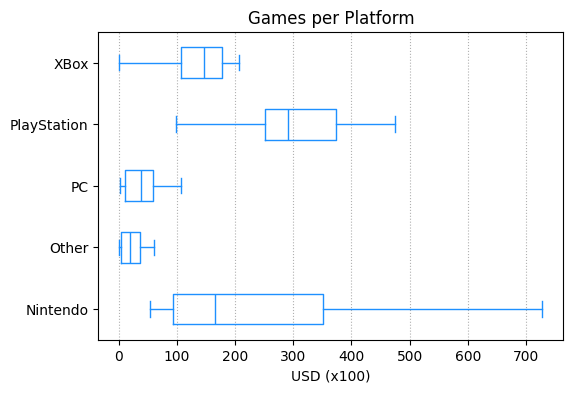

In [29]:
# Visualizar comportamiento de cantidad de juegos
games_per_platform = df_games.pivot_table(
    index = "year_of_release",
    columns = "platform_group",
    values = "name",
    aggfunc = "count"
)

games_per_platform.plot(
    kind="box",
    xlabel="USD (x100)",
    ylabel="",
    title="Games per Platform",
    vert = False,
    figsize = [6,4],
    showfliers = False,
    color = "dodgerblue"
)

plt.grid(axis = "x", linestyle = ":")
plt.show()

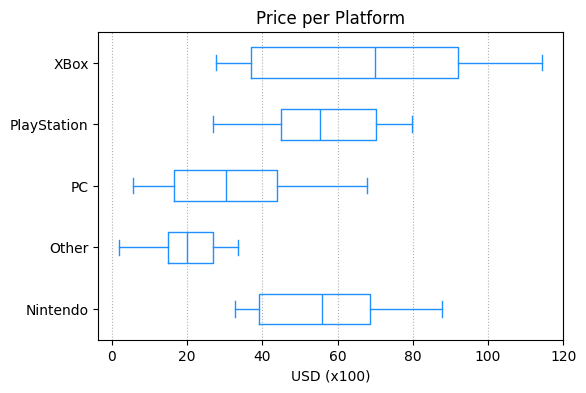

In [30]:
# Visualizar precio por juego
(100 * sales_per_platform / games_per_platform).plot(
    kind="box",
    xlabel="USD (x100)",
    ylabel="",
    title="Price per Platform",
    vert = False,
    figsize = [6,4],
    showfliers = False,
    color = "dodgerblue"
)

plt.grid(axis = "x", linestyle = ":")
plt.show()

**CONCLUSIONES**

* De los resultados observados se evidencia que no todos los grupos de plataformas son relevantes para el negocio, lo anterior visto el nivel de ventas promedio por año, la cantidad ofertada de videojuegos y el precio promedio. Por tanto conviene quedarse únicamente con Nintendo, Playstation y Xbox para los análisis subsiguientes en vista que las estrategias de la empresa se tendrían que concentrar en estas agrupaciones de consolas. 

In [31]:
# Filtrar solamente plataformas relevantes
plataformas_rel = ['Nintendo','PlayStation','XBox']
df_games = df_games.query('platform_group == @plataformas_rel')

### ¿Existen diferencias significativas en la dispersión de ventas anuales entre Nintendo y Playstation?

Para esta inferencia considera que debes usar una prueba de hipótesis distinta a las vistas hasta ahora puesto que queremos contrastar medidas de dispersión (i.e varianzas). Aquí algunas opciones disponibles:

* Bartlett: Asume que los datos muestrales distribuyen de forma normal.
* Levene: Asume que los datos muestrales NO distribuyen de forma normal.

Ejecuta ambas con un nivel de significancia del 10%.

**HIPÓTESIS NULA Y ALTERNATIVA**

* Hipótesis nula: La varianza de las ventas de Nintendo es IGUAL a la de las ventas PlayStation.
* Hipótesis alternativa: La varianza de las ventas de Nintendo es DIFERENTE a la de las ventas PlayStation.

In [32]:
# Extraer muestras para el análisis
m_Nintendo = sales_per_platform["Nintendo"]
m_Playstation = sales_per_platform["PlayStation"]

In [33]:
# Visualizar distribución de las muestras
pd.concat([m_Nintendo.describe(), m_Playstation.describe()], axis = 1).round(1)

,Nintendo,PlayStation
count,22.0,22.0
mean,134.1,161.1
std,94.9,46.7
min,19.9,36.0
25%,71.2,137.6
50%,101.0,174.6
75%,181.0,195.9
max,326.5,218.9


In [34]:
# Verificar si las varianzas son iguales o no con una prueba de Bartlett
p_bartlett = st.bartlett(m_Nintendo,m_Playstation).pvalue
print(f'Valor p: {p_bartlett:.1%}')
if p_bartlett > 0.1:
    print("No se rechaza la hipotesis nula de que las varianzas sean iguales")
else:
    print("Sí se rechaza la hipotesis nula de que las varianzas sean iguales")

Valor p: 0.2%
Sí se rechaza la hipotesis nula de que las varianzas sean iguales


In [35]:
# Verificar si las varianzas son iguales o no con una prueba de Levene
p_levene = st.levene(m_Nintendo,m_Playstation).pvalue
print(f'Valor p: {p_levene:.1%}')
if p_levene > 0.1:
    print("No se rechaza la hipotesis nula de que las varianzas sean iguales")
else:
    print("Sí se rechaza la hipotesis nula de que las varianzas sean iguales")

Valor p: 5.6%
Sí se rechaza la hipotesis nula de que las varianzas sean iguales


### ¿Existen diferencias significativas en el promedio de ventas anuales entre Nintendo y Playstation?

Utiliza los resultados alcanzados en la pregunta anterior como insumo para hacer una inferencia más robusta respecto a las medias.

**HIPÓTESIS NULA Y ALTERNATIVA**

* Hipótesis nula: El promedio de las ventas de Nintendo es IGUAL a la de las ventas PlayStation.
* Hipótesis alternativa: El promedio de las ventas de Nintendo es DIFERENTE a la de las ventas PlayStation.

In [36]:
p_ttest = st.ttest_ind(m_Nintendo,m_Playstation, equal_var = False).pvalue
print(f'Valor p: {p_ttest:.1%}')
if p_ttest > 0.1:
    print("No se rechaza la hipotesis nula de que las medias de venta anual son iguales")
else:
    print("Sí se rechaza la hipotesis nula de que las medias de venta anual son iguales")

Valor p: 24.1%
No se rechaza la hipotesis nula de que las medias de venta anual son iguales


**CONCLUSIONES**

* Nintendo y Playstation son los principales competidores en el mercado de las consolas con ventas anuales estadísticamente iguales, se recomienda por tanto que el enfoque de la empresa sea en potenciar estas plataformas considerando que la demanda está concentrada aquí. En cualquier caso, si se debe escoger entre una de las dos tipologías de consolas, convendría enfocarse en PlayStation atendiendo a su menor volatilidad en ventas de acuerdo a los resultados observados.

### Para el caso de Playstation, ¿existe alguna relación entre los scores y las ventas?

In [37]:
# Filtrar dataset solamente considerando PlayStation
df_playstation = df_games.query("platform_group == 'PlayStation'")

In [38]:
# Calcular correlación entre variables
mat_cor = df_playstation[["total_sales","critic_score","user_score"]].corr()
print(mat_cor["total_sales"])

total_sales     1.000000
critic_score    0.402449
user_score      0.127651
Name: total_sales, dtype: float64


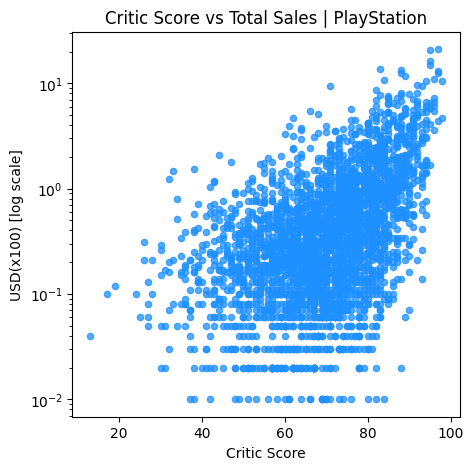

In [39]:
# Visualizar la relación entre critic_Score y total_sales
df_playstation.plot(
    kind = "scatter",
    x = "critic_score",
    y = "total_sales",
    logy = True,
    alpha = 0.75,
    xlabel = "Critic Score",
    ylabel = "USD(x100) [log scale]",
    title = "Critic Score vs Total Sales | PlayStation",
    figsize = [5,5],
    color = "dodgerblue"
)

plt.show()

**CONCLUSIONES**

* Existe una relación positiva entre la calificación de los críticos y las ventas totales de videojuegos en Playstation. En consecuencia, las estrategias comerciales de la empresa deberían enfocarse en monitorear estos scores para potenciar sus niveles de venta. En concreto, si se detectan juegos con un alto *score* de críticos se deberían generr campañas de marketing asociadas a estos productos.

### Para el caso de Playstation, ¿qué géneros y ratings de videojuegos mantienen un mayor score de críticos?

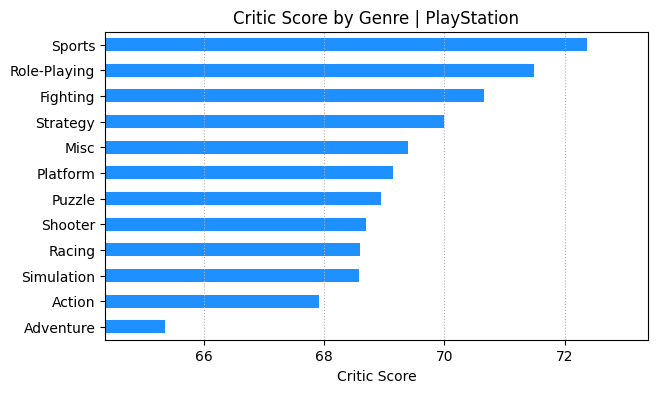

In [40]:
# Visualizar score por género
score_genre = df_playstation.groupby("genre")["critic_score"].mean().sort_values().dropna()

score_genre.plot(
    kind = "barh",
    xlim = [min(score_genre) - 1,max(score_genre) + 1],
    figsize = [7,4],
    xlabel = "Critic Score",
    ylabel = "",
    title = "Critic Score by Genre | PlayStation",
    color = "dodgerblue"
)

plt.grid(axis = "x", linestyle = ":")
plt.show()

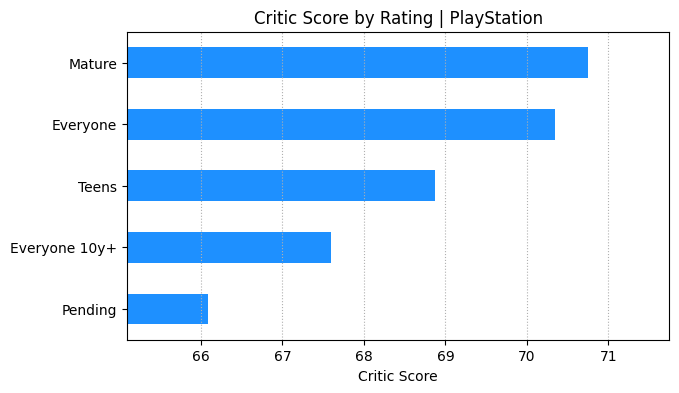

In [41]:
# Visualizar score por rating
score_rating = df_playstation.groupby("rating")["critic_score"].mean().sort_values().dropna()

score_rating.plot(
    kind = "barh",
    xlim = [min(score_rating) - 1,max(score_rating) + 1],
    figsize = [7,4],
    xlabel = "Critic Score",
    ylabel = "",
    title = "Critic Score by Rating | PlayStation",
    color = "dodgerblue"
)

plt.grid(axis = "x", linestyle = ":")
plt.show()

**CONCLUSIONES**

* Dentro de la estrategia sugerida, el enfoque comercial de la empresa debería estar en promocionar videojuegos de las categorías de Deporte, Juegos de Rol y Peleas. Además vinculando estas categorías a grupos etáreos mayores de 18 años (o que puedan acceder a contenido "Maduro"). 

### ¿Cómo es la preferencia de géneros de videojuegos en las distintas zonas geográficas?

In [42]:
# Crear tabla de participacion por genero
sales_genre = df_games.groupby('genre')[["na_sales","eu_sales","jp_sales","other_sales"]].sum()
sales_genre_s = 100 * sales_genre / sales_genre.sum()

In [43]:
# Visualizar tabla como heatmap
print("SHARE OF SALES BY GENRE AND GEOGROUP")
print("=" * 36)
sales_genre_s.style.background_gradient(cmap = "Blues", axis = "index")

SHARE OF SALES BY GENRE AND GEOGROUP


,na_sales,eu_sales,jp_sales,other_sales
genre,,,,
Action,20.618440,22.148257,14.092325,23.844393
Adventure,2.299204,2.388980,3.850595,2.057536
Fighting,5.256717,4.294325,5.719609,4.701410
Misc,9.961594,9.454632,9.540122,9.725439
Platform,8.145987,7.713998,7.355724,6.128432
Puzzle,1.826126,1.919032,3.160632,1.425684
Racing,8.751446,10.344796,4.130074,9.902143
Role-Playing,7.964606,7.416972,30.032315,7.100307
Shooter,13.149489,13.165855,2.530835,13.201965


**CONCLUSIONES**

* A nivel geográfico, la estrategia comercial para juegos del género rol debería focalizarse en Japón puesto que allí las preferencias de consumo son claras y marcadas hacía esta variedad. En cuanto a los géneros de Deportes y Peleas el enfoque estaría en el resto del mundo.